# Fit separately

=== fitting E_0 = 100, T_0 = 100 now ===
Best k_on: 0.0004, original k_on was 0.4, 1112.0 times
Total RMSE across T, E, C: 0.82


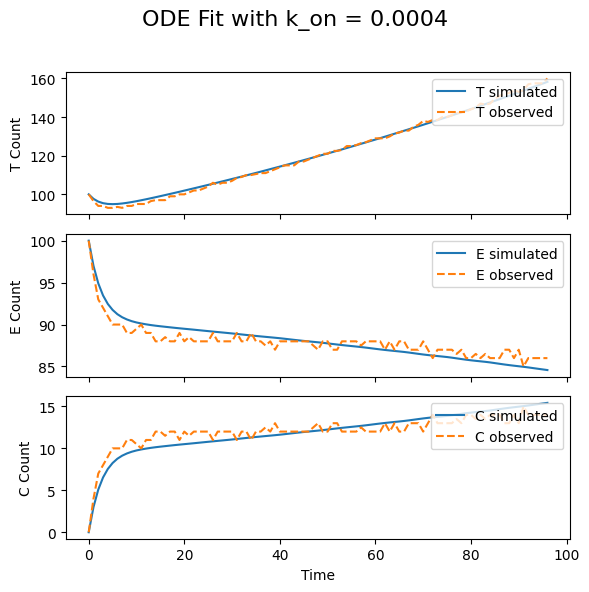

=== fitting E_0 = 100, T_0 = 1000 now ===
Best k_on: 0.0002, original k_on was 0.4, 1666.0 times
Total RMSE across T, E, C: 2.35


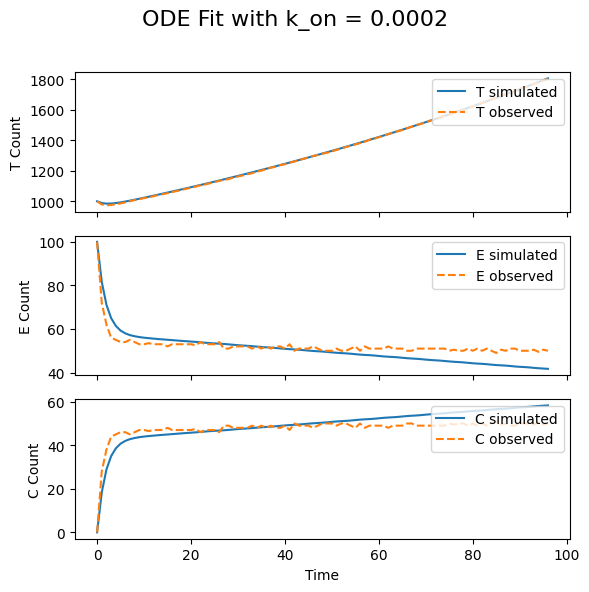

=== fitting E_0 = 1000, T_0 = 100 now ===
Best k_on: 0.0004, original k_on was 0.4, 1039.0 times
Total RMSE across T, E, C: 0.99


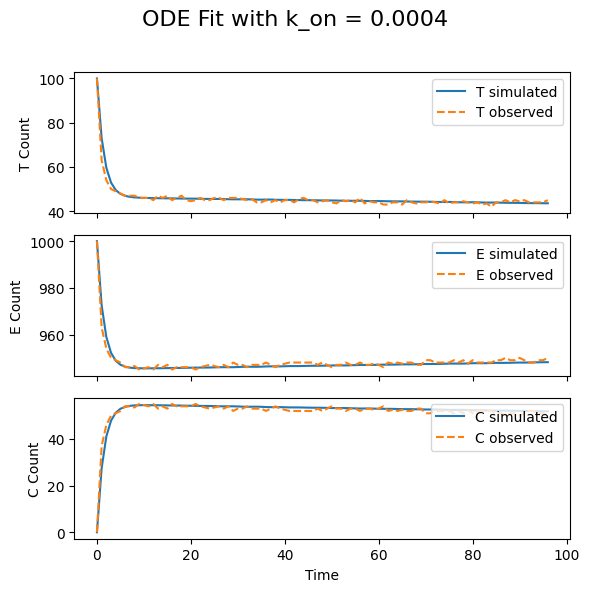

=== fitting E_0 = 1000, T_0 = 1000 now ===
Best k_on: 0.0003, original k_on was 0.4, 1346.0 times
Total RMSE across T, E, C: 5.43


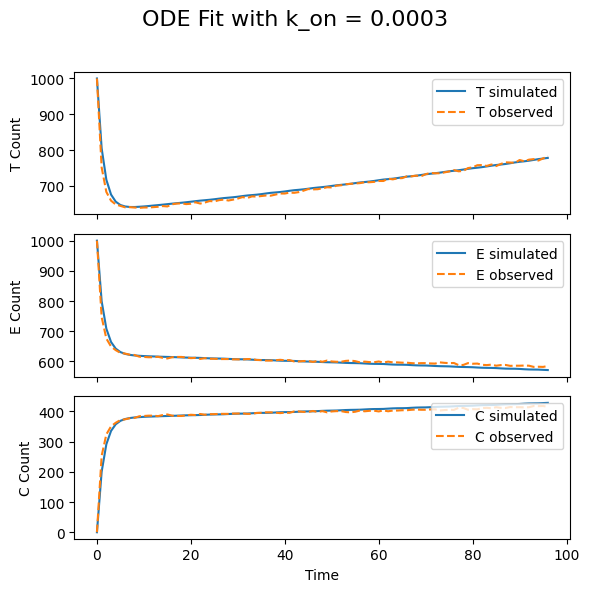

=== fitting E_0 = 1000, T_0 = 10000 now ===
Best k_on: 0.0000, original k_on was 0.4, 12033.0 times
Total RMSE across T, E, C: 34.38


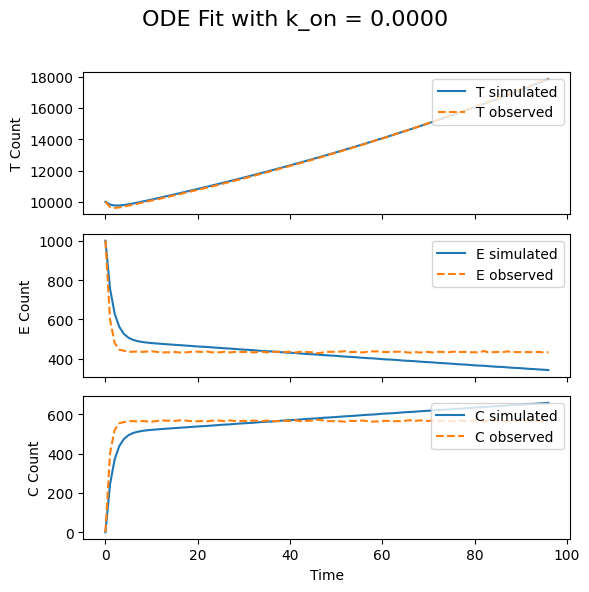

=== fitting E_0 = 10000, T_0 = 100 now ===
Best k_on: 0.0001, original k_on was 0.4, 3623.0 times
Total RMSE across T, E, C: 3.11


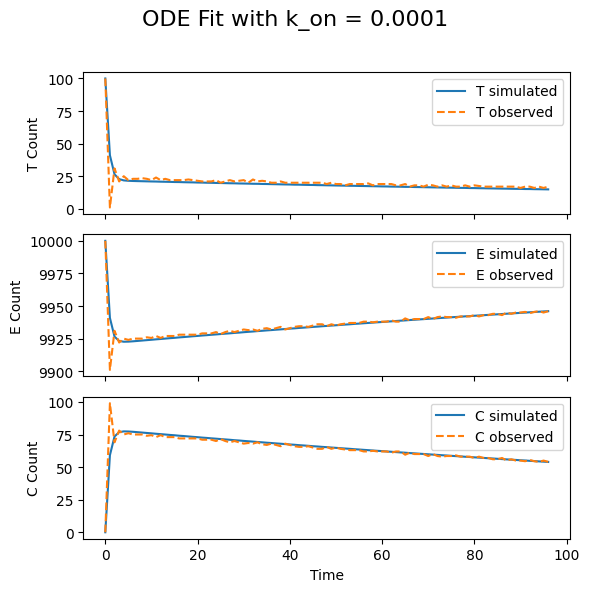

=== fitting E_0 = 10000, T_0 = 1000 now ===
Best k_on: 0.0001, original k_on was 0.4, 3456.0 times
Total RMSE across T, E, C: 29.22


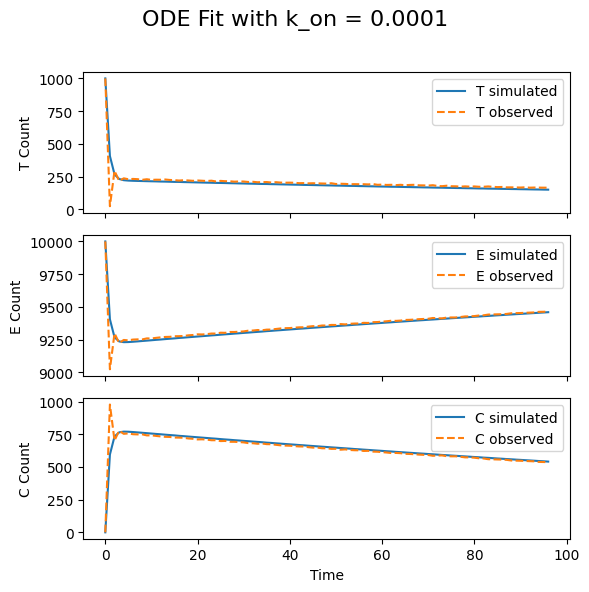

=== fitting E_0 = 10000, T_0 = 10000 now ===
Best k_on: 0.0001, original k_on was 0.4, 4289.0 times
Total RMSE across T, E, C: 68.99


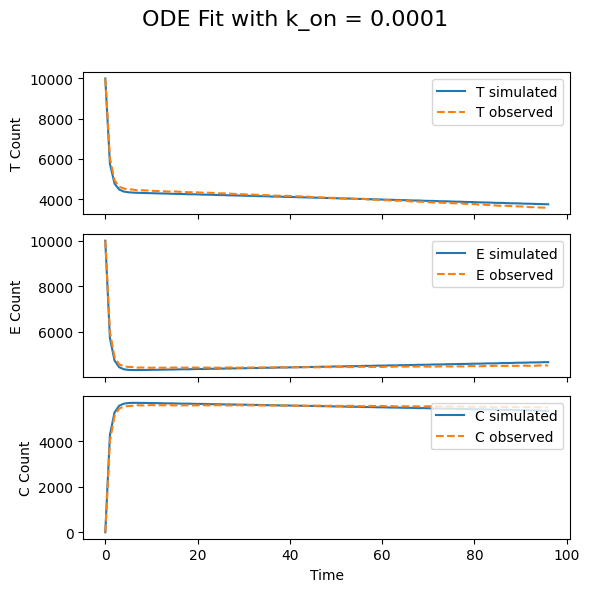


=== Summary Table (best_k_on, 0.4 // best_k_on, RMSE) ===
T_0                     100                      1000   \
E_0                                                      
100    (0.0004, 1112.0, 0.82)   (0.0002, 1666.0, 2.35)   
1000   (0.0004, 1039.0, 0.99)   (0.0003, 1346.0, 5.43)   
10000  (0.0001, 3623.0, 3.11)  (0.0001, 3456.0, 29.22)   

T_0                      10000  
E_0                             
100                        NaN  
1000     (0.0, 12033.0, 34.38)  
10000  (0.0001, 4289.0, 68.99)  


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# parameters that are consistent with ABM, not changing them
k_off = 0.3
k_kill = 0.007
g = 0.007

# Initialize result dictionary
results = {}

# Initial conditions
for E_0 in [100, 1000, 10000]:
    for T_0 in [100, 1000, 10000]:
        if E_0 < T_0 / 10:
            continue

        print(f"=== fitting E_0 = {E_0}, T_0 = {T_0} now ===")

        C_0 = 0
        z0: list[int] = [T_0, E_0, C_0]

        # Time span
        t_span: tuple[int, int] = (0, 96)
        t_eval: np.ndarray = np.linspace(*t_span, 97)

        # Load observed data
        df: pd.DataFrame = pd.read_csv(f"data/E-{E_0}_T-{T_0}_AGG.csv")
        E_obs: np.ndarray = np.array(df["E"])
        T_obs: np.ndarray = np.array(df["T"])
        C_obs: np.ndarray = np.array(df["C"])

        # ODE system with k_on as parameter
        def ode_system(t, z, k_on) -> list:
            T, E, C = z
            dTdt = g * T - k_on * E * T + k_off * C
            dEdt = -k_on * E * T + k_off * C + k_kill * C
            dCdt = k_on * E * T - k_off * C - k_kill * C
            return [dTdt, dEdt, dCdt]

        # Wrapper to solve ODE
        def solve_ode(k_on):
            sol = solve_ivp(lambda t, z: ode_system(t, z, k_on), t_span, z0, t_eval=t_eval, method="RK45")
            return sol.y  # shape: (3, len(t_eval))

        # Loss function: RMSE over all 3 curves
        def loss_fn(k_on_array):
            k_on = float(k_on_array[0])  # unpack scalar from array
            if k_on < 0:
                return np.inf
            T_sim, E_sim, C_sim = solve_ode(k_on)
            return np.mean((T_sim - T_obs) ** 2 + (E_sim - E_obs) ** 2 + (C_sim - C_obs) ** 2)

        # Optimize k_on
        res = minimize(loss_fn, x0=[0.001], bounds=[(0, 1)], method="L-BFGS-B")
        best_k_on = res.x[0]
        print(f"Best k_on: {best_k_on:.4f}, original k_on was 0.4, {0.4 // best_k_on} times")

        # Simulate with best-fit k_on
        T_sim, E_sim, C_sim = solve_ode(best_k_on)

        # Compute RMSE across all components
        all_obs = np.concatenate([T_obs, E_obs + C_obs])
        all_sim = np.concatenate([T_sim, E_sim + C_sim])
        rmse_total = np.sqrt(mean_squared_error(all_obs, all_sim))
        print(f"Total RMSE across T, E, C: {rmse_total:.2f}")

        # Store results as a tuple in the results dictionary
        results.setdefault(E_0, {})[T_0] = (round(best_k_on, 4), round(0.4 // best_k_on, 2), round(rmse_total, 2))

        # Plotting
        fig, axs = plt.subplots(3, 1, figsize=(6, 6), sharex=True)
        for ax, name, sim, obs in zip(axs, ["T", "E", "C"], [T_sim, E_sim, C_sim], [T_obs, E_obs, C_obs]):
            ax.plot(t_eval, sim, label=f"{name} simulated")
            ax.plot(t_eval, obs, "--", label=f"{name} observed")
            ax.set_ylabel(f"{name} Count")
            ax.legend(loc="upper right")

        axs[-1].set_xlabel("Time")
        fig.suptitle(f"ODE Fit with k_on = {best_k_on:.4f}", fontsize=16)
        plt.tight_layout(rect=(0, 0, 1, 0.96))
        plt.show()

# Convert to DataFrame
result_df = pd.DataFrame.from_dict(results, orient="index").sort_index(axis=0).sort_index(axis=1)
result_df.index.name = "E_0"
result_df.columns.name = "T_0"

# Display result table
print("\n=== Summary Table (best_k_on, 0.4 // best_k_on, RMSE) ===")
print(result_df)

# Fit all 9 scenarios with one set of config

## Fit K_on only


=== Best Shared Parameters ===
k_on   = 0.0003
k_off  = 0.3000
k_kill = 0.0070
g      = 0.0070
Avg Normalized RMSE = 0.27


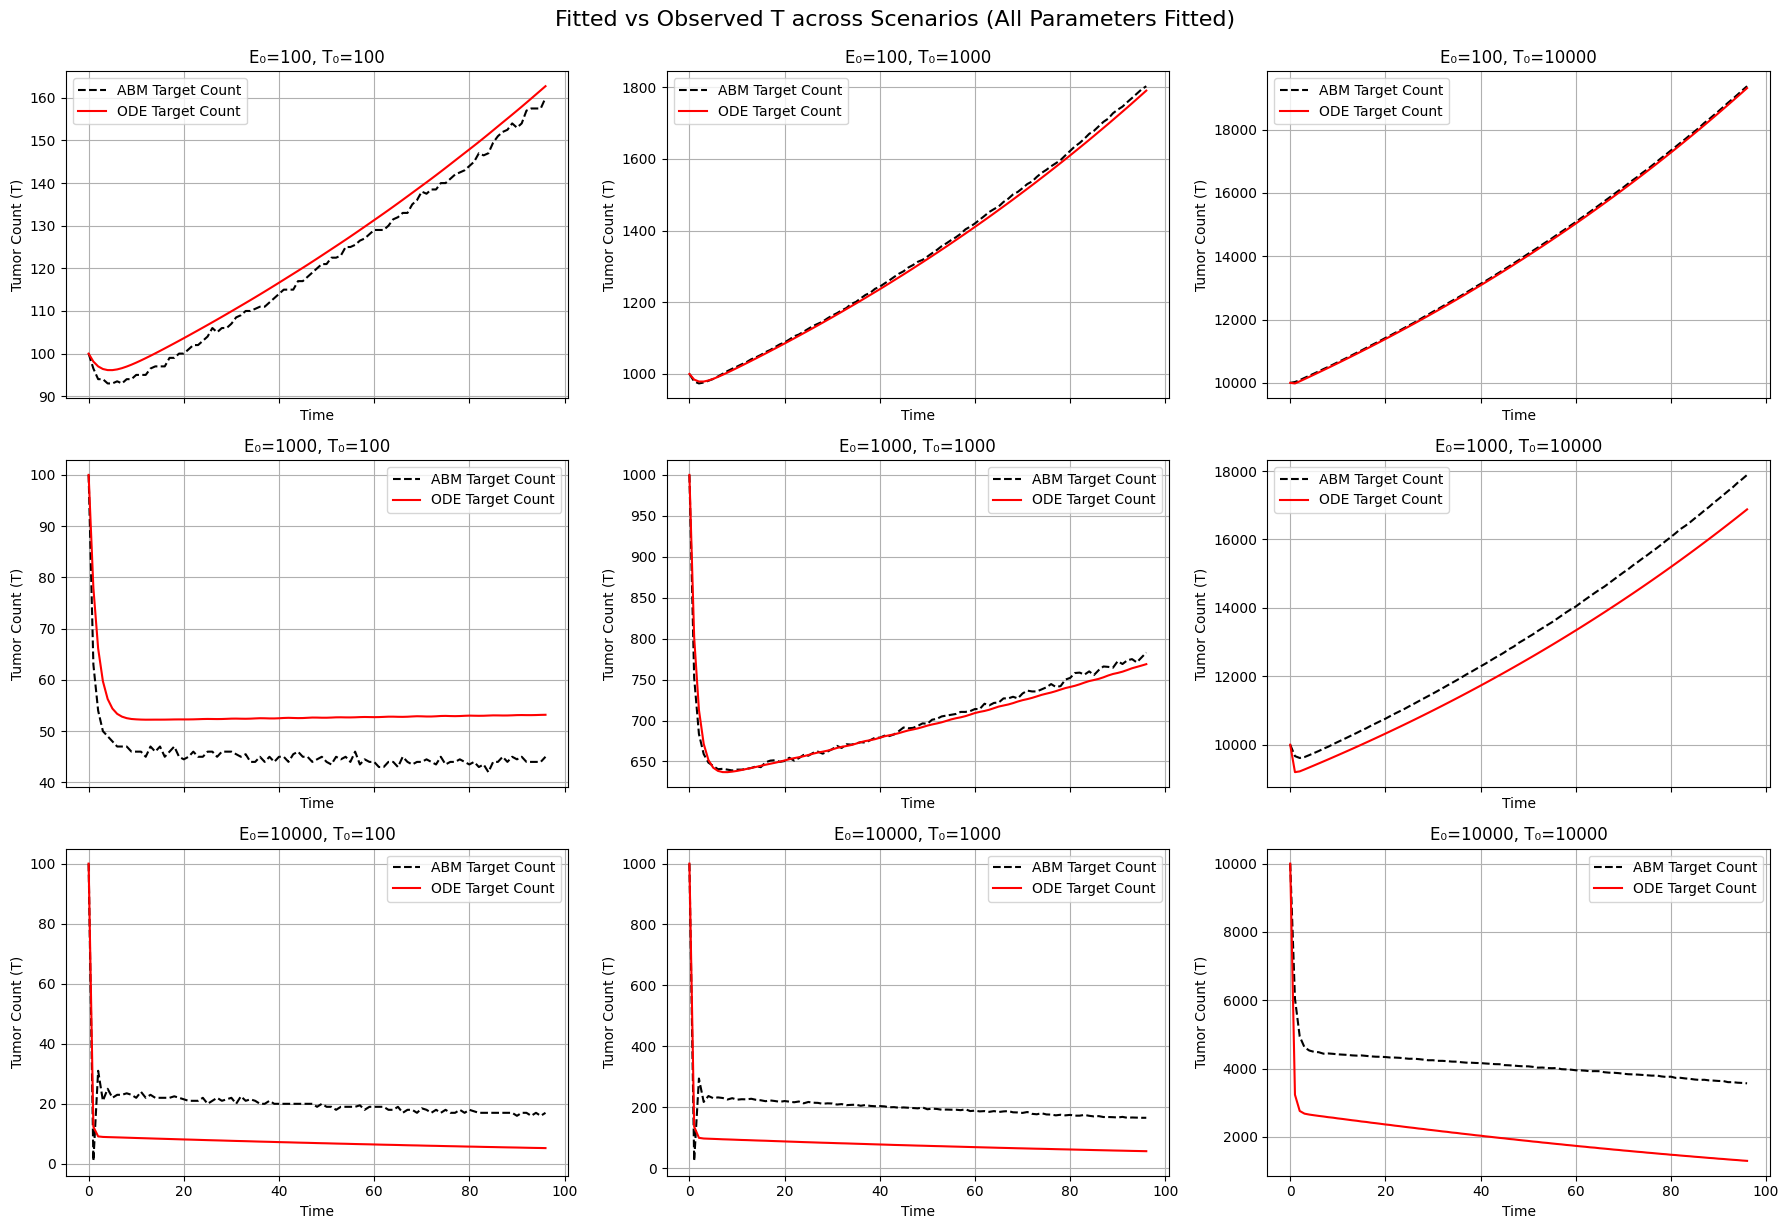

In [17]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# (E_0, T_0) pairs to fit
E_T_pairs = [(E, T) for E in [100, 1000, 10000] for T in [100, 1000, 10000]]

# Time grid based on observed data (assumed to be 97 points from t=0 to t=96)
t_span = (0, 96)
t_eval = np.linspace(*t_span, 97)

# Load observed data
all_data = {}
for E_0, T_0 in E_T_pairs:
    df = pd.read_csv(f"data/E-{E_0}_T-{T_0}_AGG.csv")
    all_data[(E_0, T_0)] = {
        "E_0": E_0,
        "T_0": T_0,
        "C_0": 0,
        "T_obs": np.array(df["T"]),
    }


# ODE system with 4 parameters: k_on, k_off, k_kill, g
def ode_system(t, z, params):
    k_on, k_off, k_kill, g = params
    T, E, C = z
    dTdt = g * T - k_on * E * T + k_off * C
    dEdt = -k_on * E * T + k_off * C + k_kill * C
    dCdt = k_on * E * T - k_off * C - k_kill * C
    return [dTdt, dEdt, dCdt]


# Simulate T(t) trajectory
def simulate_trajectory(E_0, T_0, C_0, params):
    z0 = [T_0, E_0, C_0]
    sol = solve_ivp(lambda t, z: ode_system(t, z, params), t_span, z0, t_eval=t_eval, method="RK45")
    return sol.y[0]  # Return only T(t)


# Loss function: average normalized RMSE over all scenarios, only for T
def global_loss(param_array):
    if np.any(np.array(param_array) < 0):
        return np.inf  # Reject negative params

    total = 0.0
    for (E_0, T_0), data in all_data.items():
        T_obs = data["T_obs"]
        T_sim = simulate_trajectory(E_0, T_0, data["C_0"], param_array)
        min_len = min(len(T_obs), len(T_sim))
        rmse = np.sqrt(mean_squared_error(T_obs[:min_len], T_sim[:min_len]))
        normalized_rmse = rmse / T_obs[0]
        total += normalized_rmse
    return total / len(all_data)


# Initial guess and bounds for [k_on, k_off, k_kill, g]
initial_guess = [0.0003, 0.3, 0.007, 0.007]
bounds = [(0.0001, 0.001), (0.3, 1.3), (0.007, 0.007), (0.007, 0.007)]

# Run optimization
res = minimize(global_loss, x0=initial_guess, bounds=bounds, method="L-BFGS-B")
best_params = res.x
k_on, k_off, k_kill, g = best_params

print(f"\n=== Best Shared Parameters ===")
print(f"k_on   = {k_on:.4f}")
print(f"k_off  = {k_off:.4f}")
print(f"k_kill = {k_kill:.4f}")
print(f"g      = {g:.4f}")
print(f"Avg Normalized RMSE = {np.sqrt(res.fun):.2f}")

# Plotting in a grid
num_scenarios = len(all_data)
n_cols = 3
n_rows = math.ceil(num_scenarios / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex=True)
axs = axs.flatten()

for idx, ((E_0, T_0), data) in enumerate(all_data.items()):
    T_obs = data["T_obs"]
    T_sim = simulate_trajectory(E_0, T_0, data["C_0"], best_params)
    min_len = min(len(T_obs), len(T_sim))

    ax = axs[idx]
    ax.plot(t_eval[:min_len], T_obs[:min_len], "k--", label="ABM Target Count")
    ax.plot(t_eval[:min_len], T_sim[:min_len], "r-", label="ODE Target Count")
    ax.set_title(f"E₀={E_0}, T₀={T_0}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Tumor Count (T)")
    ax.grid(True)
    ax.legend()

# Hide unused axes
for ax in axs[num_scenarios:]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Fitted vs Observed T across Scenarios (All Parameters Fitted)", fontsize=16, y=1.02)
plt.show()

## Fit all parameters


=== Best Shared Parameters ===
k_on   = 0.0004
k_off  = 0.2926
k_kill = 0.0010
g      = 0.0070
Avg Normalized RMSE = 0.25


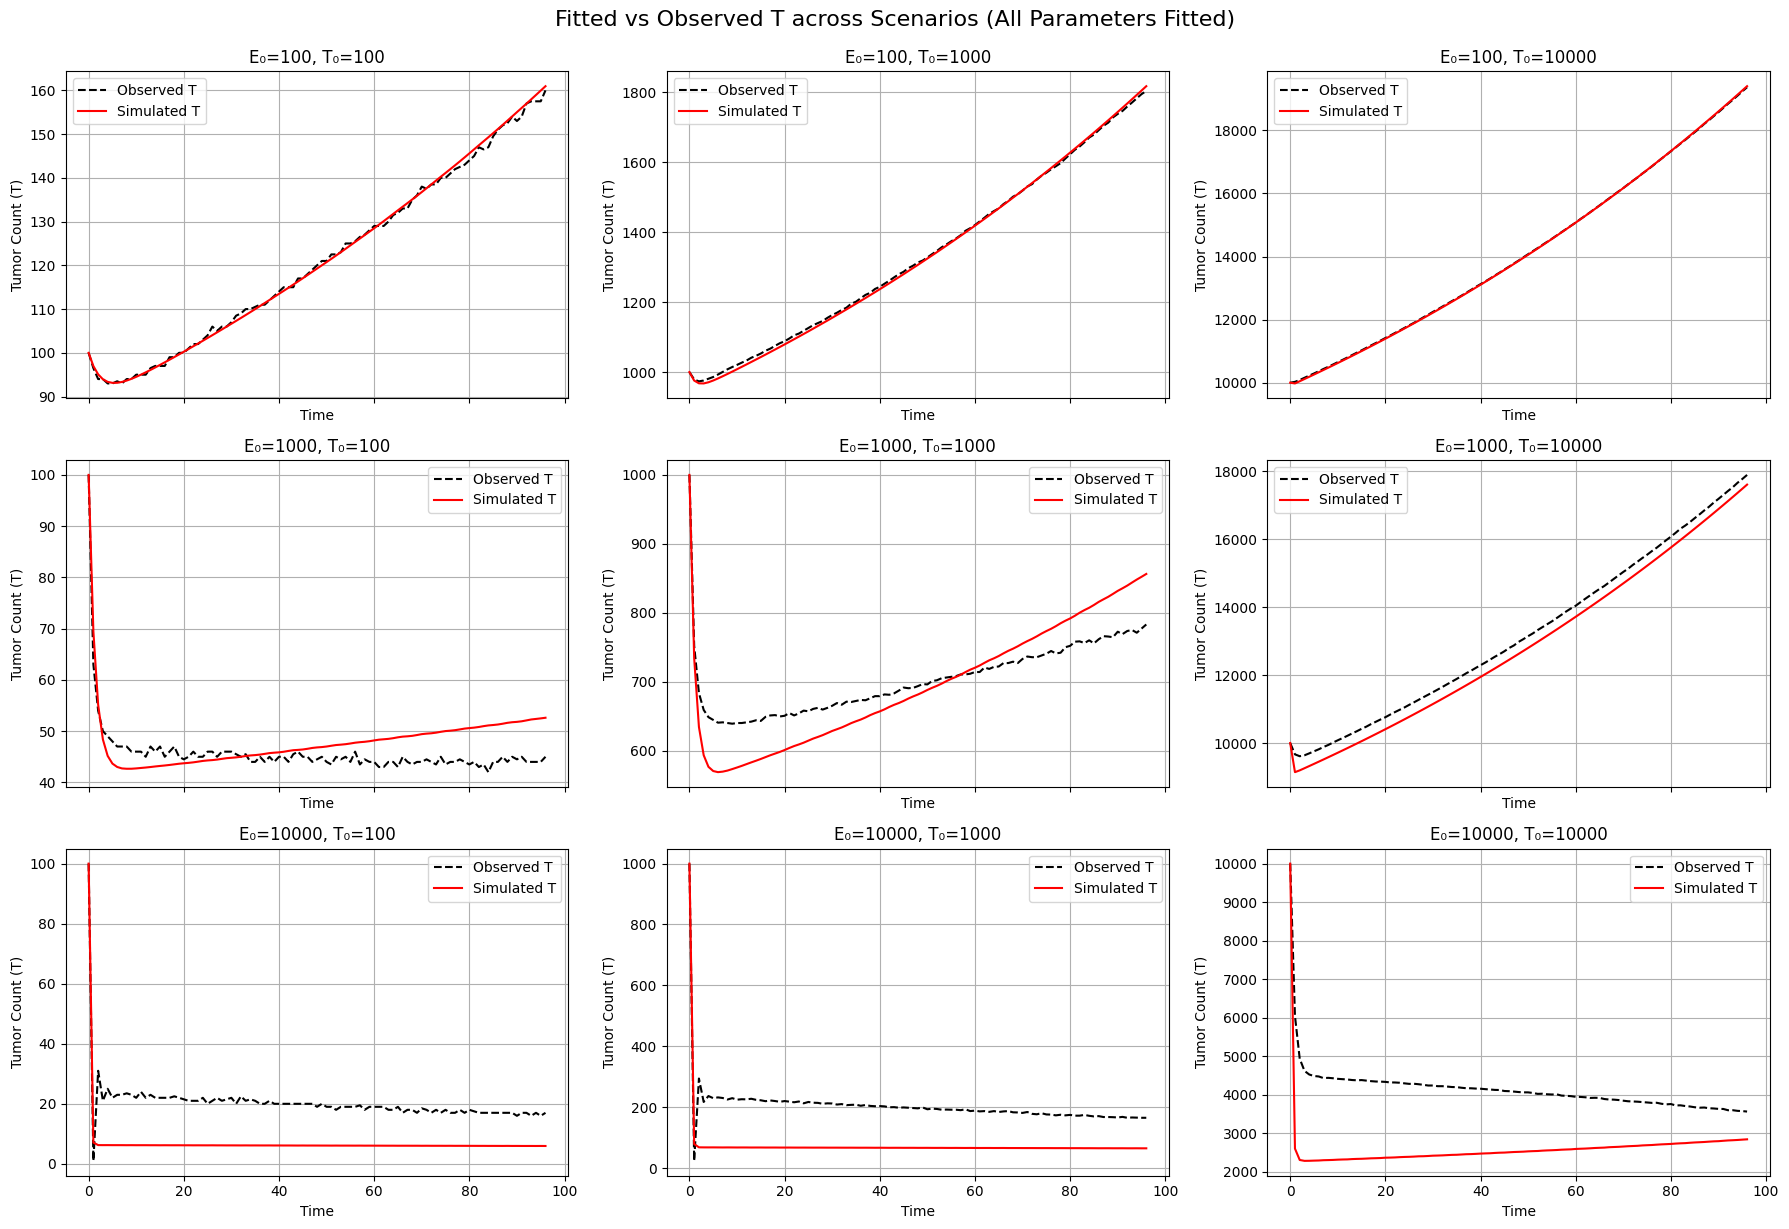

In [8]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error

# (E_0, T_0) pairs to fit
E_T_pairs = [(E, T) for E in [100, 1000, 10000] for T in [100, 1000, 10000]]

# Time grid based on observed data (assumed to be 97 points from t=0 to t=96)
t_span = (0, 96)
t_eval = np.linspace(*t_span, 97)

# Load observed data
all_data = {}
for E_0, T_0 in E_T_pairs:
    df = pd.read_csv(f"data/E-{E_0}_T-{T_0}_AGG.csv")
    all_data[(E_0, T_0)] = {
        "E_0": E_0,
        "T_0": T_0,
        "C_0": 0,
        "T_obs": np.array(df["T"]),
    }


# ODE system with 4 parameters: k_on, k_off, k_kill, g
def ode_system(t, z, params):
    k_on, k_off, k_kill, g = params
    T, E, C = z
    dTdt = g * T - k_on * E * T + k_off * C
    dEdt = -k_on * E * T + k_off * C + k_kill * C
    dCdt = k_on * E * T - k_off * C - k_kill * C
    return [dTdt, dEdt, dCdt]


# Simulate T(t) trajectory
def simulate_trajectory(E_0, T_0, C_0, params):
    z0 = [T_0, E_0, C_0]
    sol = solve_ivp(lambda t, z: ode_system(t, z, params), t_span, z0, t_eval=t_eval, method="RK45")
    return sol.y[0]  # Return only T(t)


# Loss function: average normalized RMSE over all scenarios, only for T
def global_loss(param_array):
    if np.any(np.array(param_array) < 0):
        return np.inf  # Reject negative params

    total = 0.0
    for (E_0, T_0), data in all_data.items():
        T_obs = data["T_obs"]
        T_sim = simulate_trajectory(E_0, T_0, data["C_0"], param_array)
        min_len = min(len(T_obs), len(T_sim))
        rmse = np.sqrt(mean_squared_error(T_obs[:min_len], T_sim[:min_len]))
        normalized_rmse = rmse / T_obs[0]
        total += normalized_rmse
    return total / len(all_data)


# Initial guess and bounds for [k_on, k_off, k_kill, g]
initial_guess = [0.0003, 0.3, 0.007, 0.007]
bounds = [(0.0001, 0.001), (0, 1), (0.001, 0.02), (0.001, 0.02)]

# Run optimization
res = minimize(global_loss, x0=initial_guess, bounds=bounds, method="L-BFGS-B")
best_params = res.x
k_on, k_off, k_kill, g = best_params

print(f"\n=== Best Shared Parameters ===")
print(f"k_on   = {k_on:.4f}")
print(f"k_off  = {k_off:.4f}")
print(f"k_kill = {k_kill:.4f}")
print(f"g      = {g:.4f}")
print(f"Avg Normalized RMSE = {np.sqrt(res.fun):.2f}")

# Plotting in a grid
num_scenarios = len(all_data)
n_cols = 3
n_rows = math.ceil(num_scenarios / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex=True)
axs = axs.flatten()

for idx, ((E_0, T_0), data) in enumerate(all_data.items()):
    T_obs = data["T_obs"]
    T_sim = simulate_trajectory(E_0, T_0, data["C_0"], best_params)
    min_len = min(len(T_obs), len(T_sim))

    ax = axs[idx]
    ax.plot(t_eval[:min_len], T_obs[:min_len], "k--", label="Observed T")
    ax.plot(t_eval[:min_len], T_sim[:min_len], "r-", label="Simulated T")
    ax.set_title(f"E₀={E_0}, T₀={T_0}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Tumor Count (T)")
    ax.grid(True)
    ax.legend()

# Hide unused axes
for ax in axs[num_scenarios:]:
    ax.axis("off")

plt.tight_layout()
plt.suptitle("Fitted vs Observed T across Scenarios (All Parameters Fitted)", fontsize=16, y=1.02)
plt.show()